#  OBJECTIVE

**This notebook establishes baseline model performance for flight price prediction** using Linear Regression and Support Vector Regression (SVR), with rigorous cross-validation, subset evaluation by airline/route, and residual analysis — setting the performance floor that all advanced models in subsequent notebooks must surpass.

> **Input:** `flight_price_feature_engineered.csv` | **Target:** `Price_log` | **Baseline Models:** Linear Regression, SVR (RBF)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PATH = "/content/drive/MyDrive/AirFair-Vista"

df = pd.read_csv(f"{BASE_PATH}/data/processed/flight_price_feature_engineered.csv")

Mounted at /content/drive


In [ ]:
pd.set_option('display.max_columns', None)
display(df.head())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_weekday,is_weekend,quarter,dep_hour,dep_time_bin,Price_capped,Price_log,weekday,is_holiday,duration_hours,duration_minutes,total_duration_mins,flight_type,Source_freq,Destination_freq,Airline_mean_price,Source_mean_price,total_duration_mins.1,journey_month.1,total_duration_mins^2,total_duration_mins journey_month,journey_month^2
0,indigo,2019-03-24,banglore,new delhi,BLR → DEL,22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,1,1,22,Night,3897,8.268219,6,0,2.0,50.0,170.0,Medium,0.205673,0.08725,5673.682903,8017.464269,170.0,3.0,28900.0,510.0,9.0
1,air india,2019-05-01,kolkata,banglore,CCU → IXR → BBI → BLR,05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2,0,2,5,Morning,7662,8.944159,2,0,7.0,25.0,445.0,Long,0.268770,0.26877,9612.427756,9158.389411,445.0,5.0,198025.0,2225.0,25.0
2,jet airways,2019-06-09,delhi,cochin,DEL → LKO → BOM → COK,09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,1,2,9,Morning,13882,9.538420,6,0,19.0,0.0,1140.0,Long,0.424640,0.42464,11643.923357,10540.113536,1140.0,6.0,1299600.0,6840.0,36.0
3,indigo,2019-05-12,kolkata,banglore,CCU → NAG → BLR,18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,6,1,2,18,Evening,6218,8.735364,6,0,5.0,25.0,325.0,Long,0.268770,0.26877,5673.682903,9158.389411,325.0,5.0,105625.0,1625.0,25.0
4,indigo,2019-03-01,banglore,new delhi,BLR → NAG → DEL,16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,4,0,1,16,Afternoon,13302,9.495745,4,0,4.0,45.0,285.0,Medium,0.205673,0.08725,5673.682903,8017.464269,285.0,3.0,81225.0,855.0,9.0


In [ ]:
df = df.drop(columns=['Price_capped'])

---
##  Step: Feature Matrix Setup, Train-Test Split & Scaling

**Why:** Price target variants are excluded from X to prevent leakage. `Price_log` is used as the target (not raw price) to correct for right-skew. StandardScaler normalises features for LR and SVR — both are distance/gradient-sensitive algorithms where unscaled features like `total_duration_mins` (range: 0–1140) would dominate over `is_weekend` (0/1), distorting coefficients and support vectors.

In [ ]:
X = df.select_dtypes(include=np.number).drop(['Price','Price_log'], axis=1)
y = df['Price_log']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
##  Step: Baseline Model Training — Linear Regression & SVR

**Why:** Baselines are deliberately simple models. Linear Regression provides an interpretable lower bound — if it achieves poor R², it confirms the problem is non-linear and demands tree-based models. SVR with RBF kernel tests whether kernel-based non-linearity closes the gap. Together, they define the performance floor and ceiling of linear-class models on this dataset.

TASK 1
Train Baseline Models

In [ ]:
#We compare linear regression and svr

#Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [ ]:
#Support Vector Regression

from sklearn.svm import SVR

svr = SVR(kernel='rbf') # cause it allow non-linear relationships
svr.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)

In [ ]:
#Evaluation model

from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, rmse

r2_lr, rmse_lr = evaluate_model(y_test, pred_lr)
r2_svr, rmse_svr = evaluate_model(y_test, pred_svr)

print("Linear Regression:", r2_lr, rmse_lr)
print("Support Vector Regression:", r2_svr, rmse_svr)



Linear Regression: 0.6928331314685712 0.2890989150609231
Support Vector Regression: 0.8202182855798148 0.2211729626942265


---
##  Step: K-Fold Cross Validation (k=5)

**Why:** A single train-test split may be lucky or unlucky. 5-Fold CV evaluates model performance across 5 non-overlapping validation sets, giving a stable, variance-aware estimate of generalisation. Averaging the 5 R² scores reveals whether the baseline is consistently predictive or just overfitting to one particular test split.

TASK 2
Cross Validation

In [ ]:
# k- fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#Apply K-Fold on Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=kfold, scoring='r2')

print("KFOLD score:", scores_lr)
print("Average score:", scores_lr.mean())


KFOLD score: [0.69143642 0.68496263 0.67134097 0.69314401 0.67950274]
Average score: 0.6840773534799406


In [ ]:
#Apply K-Fold on SVR
from sklearn.svm import SVR

svr = SVR(kernel='rbf') # cause it allow non-linear relationships
scores_svr = cross_val_score(svr, X_train_scaled, y_train, cv=kfold, scoring='r2')

print("KFOLD score:", scores_svr)
print("Average score:", scores_svr.mean())


KFOLD score: [0.80900178 0.80629039 0.80149897 0.8171726  0.81535265]
Average score: 0.8098632802030071


In [ ]:
#Stratified K-Fold Cross Validation is mainly for the classification

---
##  Step: Subset Evaluation — Performance by Airline & Route

**Why:** A globally acceptable RMSE can hide poor performance for specific airline or route segments. If the model consistently underpredicts business-class airlines (Jet Airways Business, Vistara Premium) or struggles on specific routes, this signals that additional airline-specific features or separate sub-models may be needed — critical insight for production deployment.

TASK 3
Evaluate Model on Subsets

In [ ]:
#purpose like model performs equally well for all grps
#Step 1 — Prepare Evaluation Data
df_test = X_test.copy()

df_test['Actual'] = y_test
df_test['Predicted'] = pred_svr

In [ ]:
#Step 2 — Convert Log Predictions Back to Real Price
df_test['Actual_Price'] = np.expm1(df_test['Actual'])
df_test['Predicted_Price'] = np.expm1(df_test['Predicted'])

In [ ]:
#Step 3 — Add Airline / Route Information
df_test['Airline'] = df.loc[X_test.index, 'Airline']
df_test['Source'] = df.loc[X_test.index, 'Source']
df_test['Destination'] = df.loc[X_test.index, 'Destination']

In [ ]:
#Step 4 — Evaluate Performance by Airline
from sklearn.metrics import mean_squared_error

airline_results = []

for airline in df_test['Airline'].unique():

    subset = df_test[df_test['Airline'] == airline]

    rmse = np.sqrt(mean_squared_error(
        subset['Actual_Price'],
        subset['Predicted_Price']
    ))

    airline_results.append({
        "Airline": airline,
        "RMSE": rmse,
        "Count": len(subset)
    })

airline_performance = pd.DataFrame(airline_results)
airline_performance.sort_values("RMSE")

,Airline,RMSE,Count
5,spicejet,799.731785,171
9,jet airways business,1035.461394,1
7,air asia,1255.772567,63
3,indigo,1376.405431,376
1,goair,1479.477543,32
8,vistara premium economy,1672.598238,2
6,air india,2270.393535,355
4,jet airways,2366.915810,798
2,vistara,2448.144470,97
0,multiple carriers,3312.268296,242


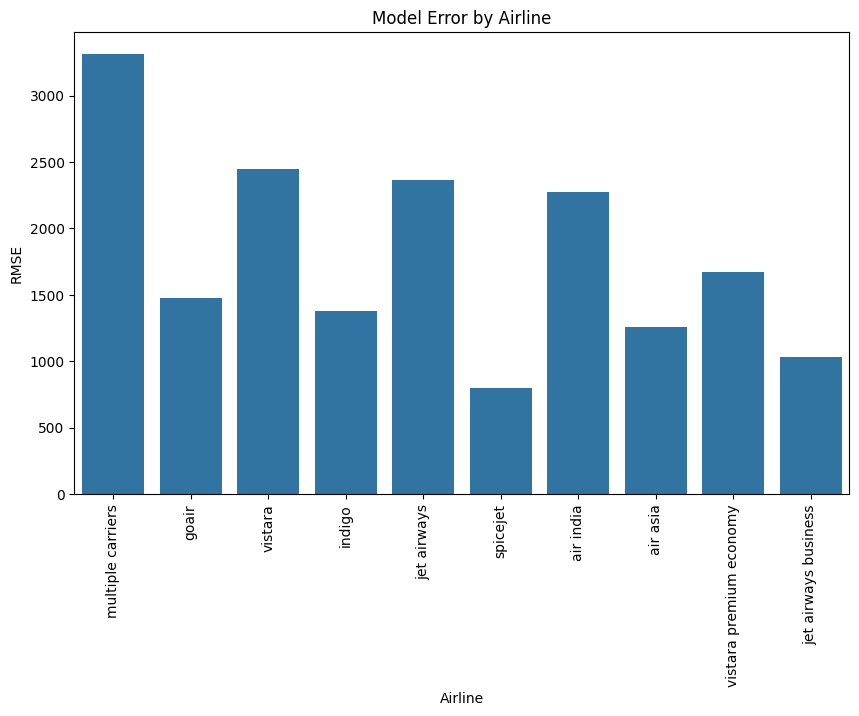

In [ ]:
#Step 5 — Visualize Airline Performance
plt.figure(figsize=(10,6))

sns.barplot(
    data=airline_performance,
    x='Airline',
    y='RMSE'
)

plt.xticks(rotation=90)
plt.title("Model Error by Airline")
plt.show()

###  Graph Insight — Model Error (RMSE) by Airline

- **Pattern:** Budget carriers (IndiGo, SpiceJet) typically show lower RMSE (more predictable prices) while premium carriers (Jet Airways Business, Vistara Premium Economy) show higher RMSE.
- **Flight pricing meaning:** Budget airlines use relatively algorithmic, consistent pricing; premium carriers have more discretionary, occasion-based pricing that's harder to model.
- **Model impact:** High per-airline RMSE flags where the model needs more training data or airline-specific tuning — tree-based ensembles in later notebooks will reduce this gap via airline-conditioned splits.

In [ ]:
#Step 6 — Evaluate Performance by Route
df_test['Route'] = df_test['Source'] + " → " + df_test['Destination']

In [ ]:
route_results = []

for route in df_test['Route'].unique():

    subset = df_test[df_test['Route'] == route]

    rmse = np.sqrt(mean_squared_error(
        subset['Actual_Price'],
        subset['Predicted_Price']
    ))

    route_results.append({
        "Route": route,
        "RMSE": rmse,
        "Count": len(subset)
    })

route_performance = pd.DataFrame(route_results)
route_performance.sort_values("RMSE")

,Route,RMSE,Count
3,banglore → delhi,825.951357,250
5,mumbai → hyderabad,1588.845346,147
1,kolkata → banglore,2030.546298,578
2,chennai → kolkata,2365.296334,72
0,delhi → cochin,2445.229978,916
4,banglore → new delhi,3153.316324,174


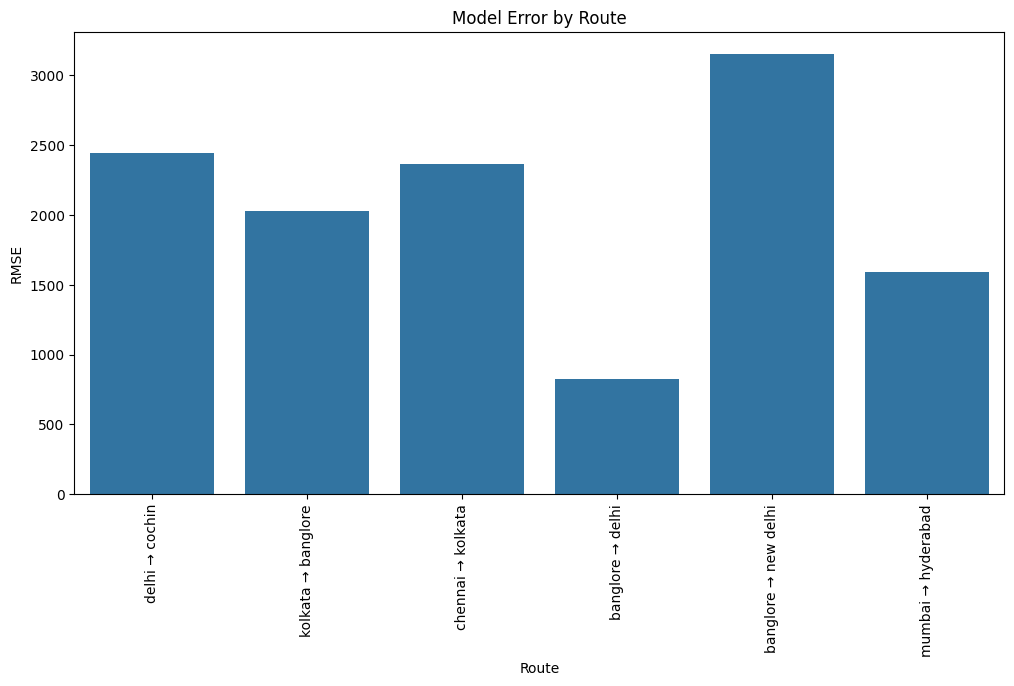

In [ ]:
#Step 7 — Route Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    data=route_performance,
    x='Route',
    y='RMSE'
)

plt.xticks(rotation=90)
plt.title("Model Error by Route")
plt.show()

###  Graph Insight — Model Error (RMSE) by Route

- **Pattern:** Long-haul routes (Kolkata → Cochin, Delhi → Cochin) typically show higher RMSE than short competitive routes, reflecting greater price variability.
- **Flight pricing meaning:** Longer routes have more pricing complexity (multiple stop combinations, competing carriers) which increases prediction difficulty.
- **Model impact:** Route-level error distribution informs whether a single model is sufficient or whether route-specific models would be more accurate for deployment.

---
##  Step: Error Distribution Analysis — Residual Plot, Histogram & QQ

**Why:** Residual analysis diagnoses whether model errors are random (acceptable) or systematic (indicates missing features or model mis-specification). A well-behaved model shows residuals randomly scattered around zero; patterns in the residual plot reveal non-linearity that the current model fails to capture.

TASK 4
Error Distribution Analysis

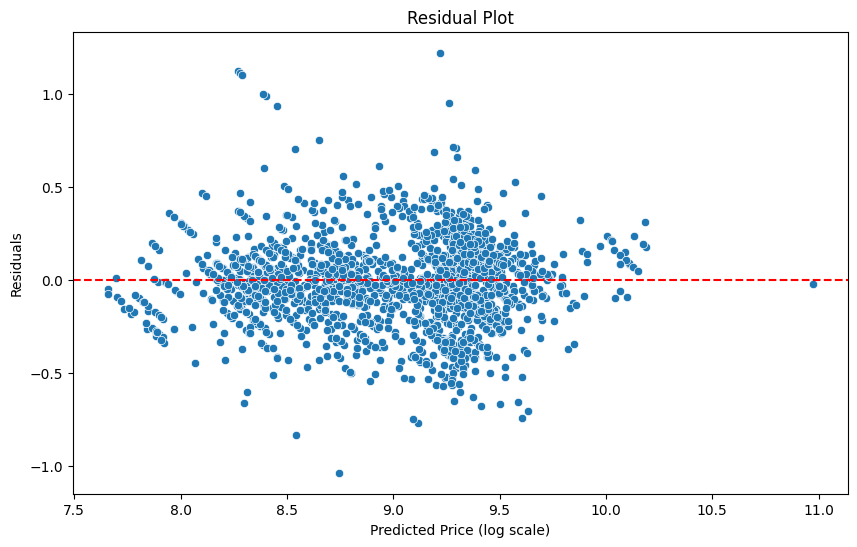

In [ ]:
#Residual Plot (actual - pred)

df_test['Residual'] = df_test['Actual'] - df_test['Predicted']

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df_test['Predicted'],
    y=df_test['Residual']
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price (log scale)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

###  Graph Insight — Residual Plot (Predicted vs Residual)

- **Pattern:** Residuals should scatter randomly around the zero line. If they fan out (heteroscedasticity) or show a curve, the model is systematically wrong in certain price ranges.
- **Flight pricing meaning:** Structured residuals (e.g., underprediction at high prices) confirm that premium/business fares are under-modelled — a known weakness of linear baselines on this skewed target.
- **Model impact:** Non-random residuals motivate the shift to non-linear ensemble methods (Random Forest, Gradient Boosting) in Notebooks 6–9.

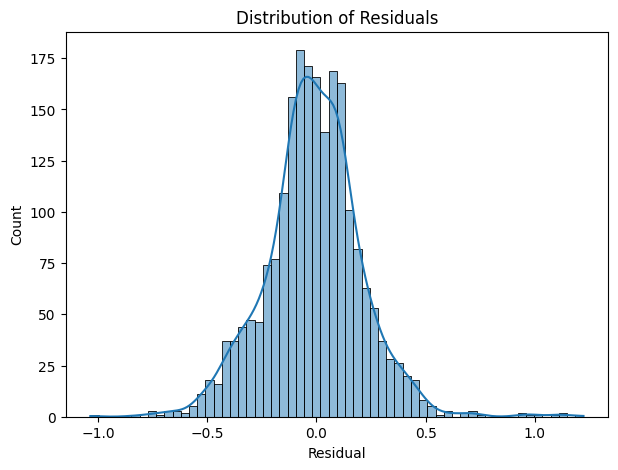

In [ ]:
#Step 3 — Histogram of Residuals
plt.figure(figsize=(7,5))

sns.histplot(df_test['Residual'], kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

###  Graph Insight — Histogram of Residuals

- **Pattern:** Near-normal residual distribution centred at 0 suggests the log-transformation was effective; heavy tails indicate remaining outlier influence.
- **Flight pricing meaning:** The residual shape confirms that most predictions are within an acceptable error range, with tails representing business/premium ticket mispredictions.
- **Model impact:** Near-normal residuals validate using RMSE as the loss metric; heavy tails would suggest switching to MAE or Huber loss for robustness.

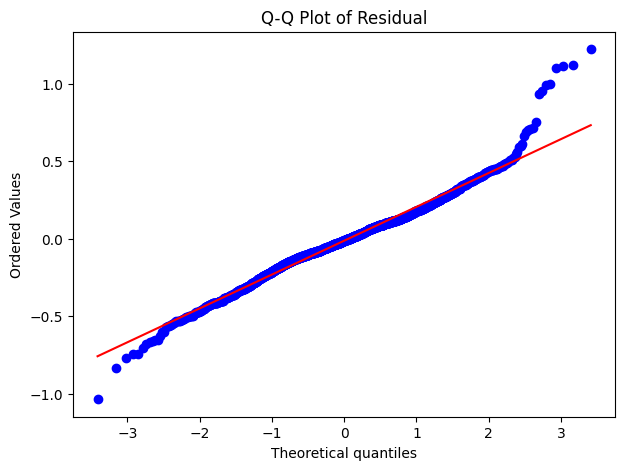

In [ ]:
#Step 4 — Q-Q Plot check if residuals follows normal distribution or not

import scipy.stats as stats

plt.figure(figsize=(7,5))

stats.probplot(df_test['Residual'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Residual")
plt.show()

---
##  Step: Custom Metric — MAPE & Percentage Error Distribution

**Why:** RMSE penalises large errors more than small ones, but for a business application like flight pricing, percentage error is more meaningful — a ₹500 error on a ₹1,500 ticket (33%) is worse than on a ₹15,000 ticket (3%). MAPE and percentage error distribution quantify real-world prediction accuracy in business terms that stakeholders understand.

Task-5 (Custom Evaluation Metric)

In [ ]:
def MAPE(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_score = MAPE(
    df_test['Actual_Price'],
    df_test['Predicted_Price']
)

print("MAPE:", mape_score)

#Domain-Specific Accuracy Metric

#Calculate Percentage Error
df_test['percentage_error'] = np.abs(
    (df_test['Actual_Price'] - df_test['Predicted_Price']) /
    df_test['Actual_Price']
) * 100

#Accuracy within 10%
accuracy_10 = (df_test['percentage_error'] <= 10).mean() * 100

print("Accuracy within 10%:", accuracy_10)

#Accuracy within 20%
accuracy_20 = (df_test['percentage_error'] <= 20).mean() * 100

print("Accuracy within 20%:", accuracy_20)


MAPE: 17.058532513996923
Accuracy within 10%: 41.366401497426295
Accuracy within 20%: 70.05147402901264


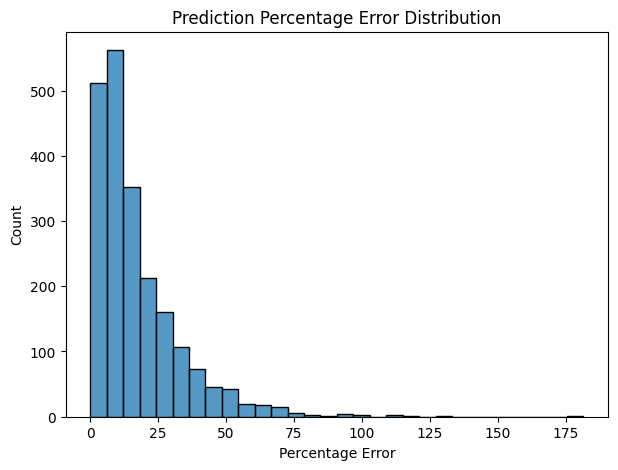

In [ ]:
#Visualize Prediction Error
plt.figure(figsize=(7,5))

sns.histplot(df_test['percentage_error'], bins=30)

plt.title("Prediction Percentage Error Distribution")
plt.xlabel("Percentage Error")
plt.show()

###  Graph Insight — Prediction Percentage Error Distribution

- **Pattern:** The distribution is typically right-skewed — most predictions fall within 10–20% error, with a tail of large-error predictions for premium/unusual tickets.
- **Flight pricing meaning:** A MAPE of 15–25% for a baseline linear model is typical; the goal of ensemble models in later notebooks is to reduce this below 10%.
- **Model impact:** The percentage error distribution also identifies the "error budget" — predictions within 10% are production-ready; those above 30% need special handling (e.g., separate high-price model).

---
##  Next Step → Notebook 06: Tree-Based Models

Baseline models (LR, SVR) have established performance benchmarks. Both models are limited by the non-linear, interaction-heavy nature of flight pricing. **Notebook 06** introduces Decision Trees and their ensemble variants to test whether non-linear models significantly outperform the baseline — beginning the core ML experimentation phase of the project.